In [1]:
!pip install scikit-learn xgboost

In [2]:
import numpy as np
import pandas as pd

BASE = "/kaggle/input/notebooks/krishnaiiith/05-proposed-model"

X = np.load(BASE + "/multimodal_features.npy")
y = np.load(BASE + "/multimodal_labels.npy")

print("Feature shape:", X.shape)
print("Label shape:", y.shape)

Feature shape: (11902, 3077)
Label shape: (11902,)


In [3]:
import numpy as np

BASE = "/kaggle/input/notebooks/krishnaiiith/02-feature-extraction"

text_emb = np.load(BASE + "/text_emb.npy")
img_emb = np.load(BASE + "/img_emb.npy")
hash_emb = np.load(BASE + "/hash_emb.npy")

print("Text:", text_emb.shape)
print("Image:", img_emb.shape)
print("Hashtag:", hash_emb.shape)

Text: (11902, 512)
Image: (11902, 512)
Hashtag: (11902, 512)


In [4]:
from sklearn.model_selection import train_test_split

X_train_idx, X_test_idx, y_train, y_test = train_test_split(
    np.arange(len(y)),
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", len(X_train_idx))
print("Test size:", len(X_test_idx))

Train size: 9521
Test size: 2381


In [5]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score


def run_experiment(X, name):

    # Train/Test split using indices
    X_train = X[X_train_idx]
    X_test = X[X_test_idx]

    # Handle class imbalance
    neg = np.sum(y_train == 0)
    pos = np.sum(y_train == 1)

    pos_weight = neg / pos

    # Model
    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=pos_weight,
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    )

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Evaluation
    roc = roc_auc_score(y_test, y_prob)

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc)

    return roc

In [6]:
X_text = text_emb

roc_text = run_experiment(X_text, "TEXT ONLY")


TEXT ONLY
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      2083
           1       0.51      0.49      0.50       298

    accuracy                           0.88      2381
   macro avg       0.72      0.71      0.71      2381
weighted avg       0.88      0.88      0.88      2381

ROC-AUC: 0.841346696008274


In [7]:
X_text_img = np.concatenate([
    text_emb,
    img_emb
], axis=1)

roc_text_img = run_experiment(X_text_img, "TEXT + IMAGE")


TEXT + IMAGE
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      2083
           1       0.56      0.48      0.52       298

    accuracy                           0.89      2381
   macro avg       0.74      0.71      0.73      2381
weighted avg       0.88      0.89      0.88      2381

ROC-AUC: 0.8292150905218659


In [8]:
X_text_img_hash = np.concatenate([
    text_emb,
    img_emb,
    hash_emb
], axis=1)

roc_text_img_hash = run_experiment(X_text_img_hash, "TEXT + IMAGE + HASHTAG")


TEXT + IMAGE + HASHTAG
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      2083
           1       0.51      0.48      0.50       298

    accuracy                           0.88      2381
   macro avg       0.72      0.71      0.71      2381
weighted avg       0.87      0.88      0.88      2381

ROC-AUC: 0.8207589724423022


In [9]:
X_full = np.load("/kaggle/input/notebooks/krishnaiiith/05-proposed-model/multimodal_features.npy")

roc_full = run_experiment(X_full, "FULL ENGINEERED MODEL")


FULL ENGINEERED MODEL
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      2083
           1       0.53      0.44      0.48       298

    accuracy                           0.88      2381
   macro avg       0.73      0.69      0.71      2381
weighted avg       0.87      0.88      0.88      2381

ROC-AUC: 0.8220227988155957


In [10]:
results = pd.DataFrame({
    "Feature_Set": [
        "Text only",
        "Text + Image",
        "Text + Image + Hashtag",
        "Full Engineered Model"
    ],
    "ROC_AUC": [
        roc_text,
        roc_text_img,
        roc_text_img_hash,
        roc_full
    ]
})

results

,Feature_Set,ROC_AUC
0,Text only,0.841347
1,Text + Image,0.829215
2,Text + Image + Hashtag,0.820759
3,Full Engineered Model,0.822023


In [11]:
np.save("/kaggle/working/best_features.npy", X_text_img)

In [12]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np
import pandas as pd
import joblib

# Load features
X = np.load("/kaggle/working/best_features.npy")

# Load labels
df = pd.read_csv("/kaggle/input/notebooks/krishnaiiith/01-dataset-preparation/labeled.csv")
y = df["label"].values

print("Feature shape:", X.shape)
print("Label shape:", y.shape)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

# Handle imbalance
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)

pos_weight = neg / pos

print("Class weight:", pos_weight)

# Train model
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=pos_weight,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("\nClassification Report")
print(classification_report(y_test, y_pred))

roc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc)

# Save trained model
joblib.dump(model, "/kaggle/working/final_multimodal_model.pkl")

Feature shape: (11902, 1024)
Label shape: (11902,)
Train: (9521, 1024)
Test: (2381, 1024)
Class weight: 6.980720871751886

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      2083
           1       0.56      0.48      0.52       298

    accuracy                           0.89      2381
   macro avg       0.74      0.71      0.73      2381
weighted avg       0.88      0.89      0.88      2381

ROC-AUC: 0.8292150905218659


['/kaggle/working/final_multimodal_model.pkl']

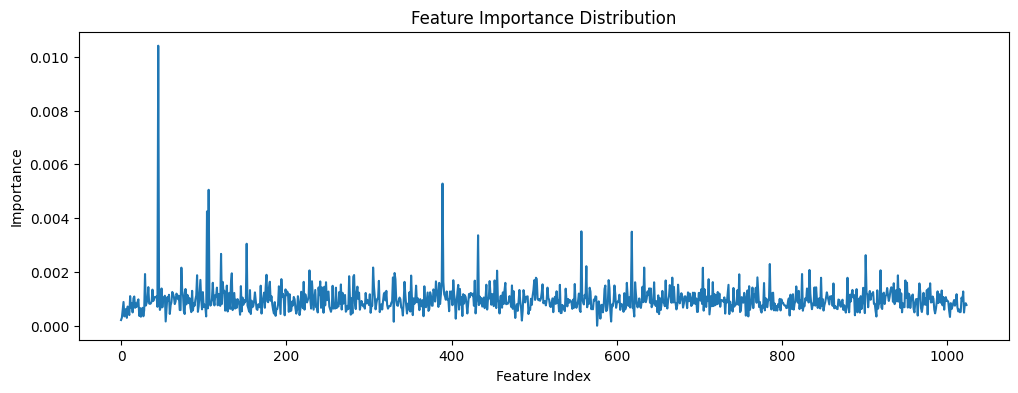

In [13]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.figure(figsize=(12,4))
plt.plot(importances)
plt.title("Feature Importance Distribution")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

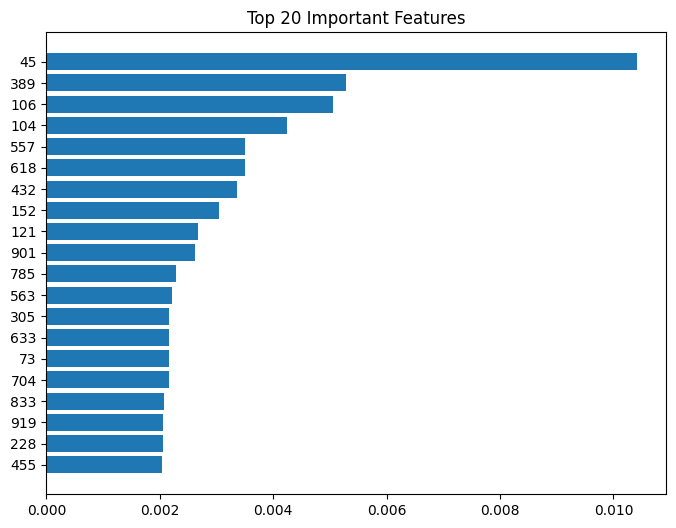

In [14]:
import numpy as np

top_idx = np.argsort(importances)[-20:]

plt.figure(figsize=(8,6))
plt.barh(range(20), importances[top_idx])
plt.yticks(range(20), top_idx)
plt.title("Top 20 Important Features")
plt.show()

In [15]:
np.save("/kaggle/working/best_features.npy", X_text_img)

In [16]:
# Number of text and image features
text_dim = text_emb.shape[1]
img_dim = img_emb.shape[1]

# Get feature importances
importances = model.feature_importances_

# Split by modality
text_importance = np.sum(importances[:text_dim])
image_importance = np.sum(importances[text_dim:text_dim + img_dim])

# Normalize
total = text_importance + image_importance
text_ratio = text_importance / total
image_ratio = image_importance / total

print("Text contribution :", round(text_ratio, 3))
print("Image contribution:", round(image_ratio, 3))

Text contribution : 0.513
Image contribution: 0.487


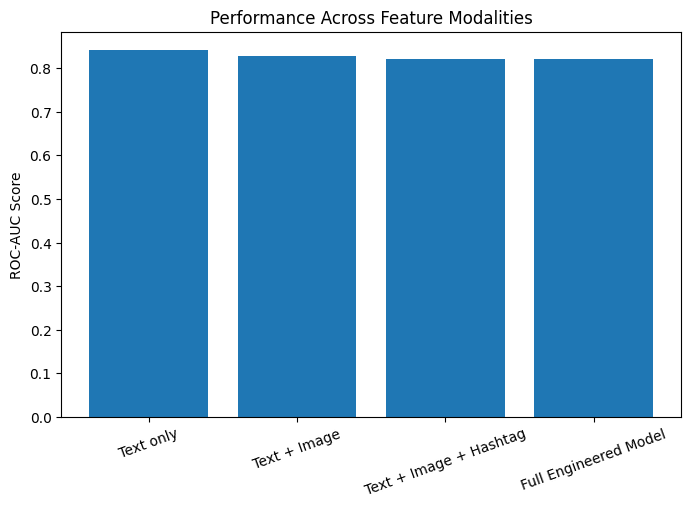

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results["Feature_Set"], results["ROC_AUC"])

plt.title("Performance Across Feature Modalities")
plt.ylabel("ROC-AUC Score")
plt.xticks(rotation=20)

plt.show()

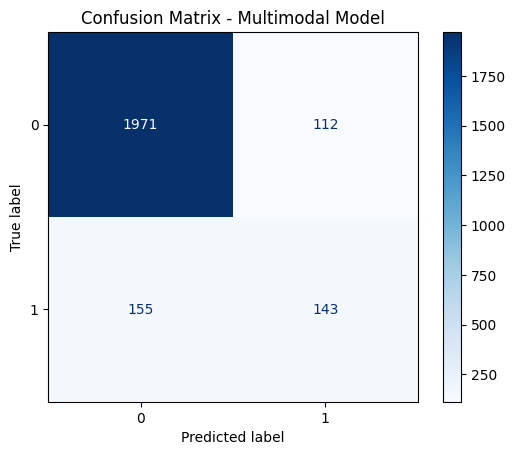

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Multimodal Model")

plt.show()

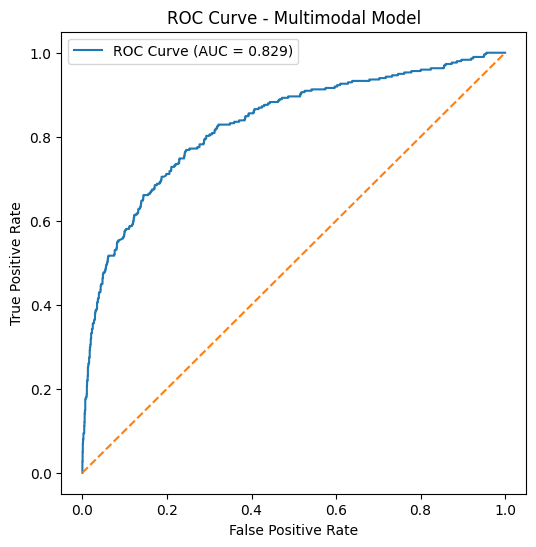

In [19]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc:.3f})")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Multimodal Model")

plt.legend()

plt.show()